# LUCY -- Notebook 3: JAAD + Synthetic Mixed Training
## TrafficRiskNet fine-tuned with real pedestrian trajectories

**Pipeline:**
```
JAAD XMLs (346 videos, frame-level ped annotations)
  + Synthetic generators (Notebook 1)
  --> balanced dataset --> TrafficRiskNet --> traffic_risk_jaad.pth
```
**Why JAAD?** Real pedestrian bounding boxes with behavioral labels
(`cross=crossing/not-crossing`, `action=standing/walking`, `look=looking/not-looking`).
We derive SAFE/WARNING/CRITICAL labels from these attributes.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, glob, random, warnings
from pathlib import Path
from collections import defaultdict, Counter
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
warnings.filterwarnings('ignore')

try:
    from sklearn.metrics import (confusion_matrix, classification_report,
                                  roc_curve, auc, ConfusionMatrixDisplay)
    import seaborn as sns
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print('[WARN] sklearn/seaborn not found -- install with: pip install scikit-learn seaborn')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.makedirs('models', exist_ok=True)
os.makedirs('output', exist_ok=True)
print(f'Device: {DEVICE}  |  sklearn: {HAS_SKLEARN}')

Device: cuda  |  sklearn: True


In [2]:
# ── Constants ────────────────────────────────────────────────────────────────
RISK_CLASSES    = ['SAFE', 'WARNING', 'CRITICAL']
N_RISK          = 3
N_COCO_CLASSES  = 80
D_MODEL         = 64
MAX_OBJECTS     = 20
SEQ_LEN         = 15
GRU_HIDDEN      = 128
GRU_LAYERS      = 2

JAAD_DIR         = 'datasets/jaad_annotations/annotations'
MAX_XMLS         = 150        # XMLs to parse (of 346 total)
WIN_STEP         = 7          # sliding-window stride in frames
TARGET_JAAD      = 1200       # JAAD sequences per class (after balancing)
TARGET_SYNTH     = 1000       # synthetic sequences per class
EPOCHS           = 50
BATCH_SIZE       = 64
LR               = 3e-4
WEIGHT_DECAY     = 1e-4
SAVE_PATH        = 'models/traffic_risk_jaad.pth'
SYNTH_PATH       = 'models/traffic_risk_best.pth'  # from Notebook 1

print('Constants OK')

Constants OK


## 1. Parse JAAD Annotations

In [3]:
def _add_vehicle_context(rng, ped_cx, ped_cy, label):
    '''Inject synthetic vehicles around a pedestrian based on risk label.'''
    vehs = []
    if label == 0:   # SAFE -- distant or absent vehicle
        if rng.random() < 0.35:
            vx = float(np.clip(ped_cx + rng.uniform(0.35, 0.6) * rng.choice([-1,1]), 0.05, 0.95))
            vehs.append([2.0, vx, float(ped_cy), rng.uniform(0.04,0.09), rng.uniform(0.04,0.08), rng.uniform(0.6,0.85)])
    elif label == 1: # WARNING -- medium distance
        offset = rng.uniform(0.14, 0.28) * rng.choice([-1,1])
        vx = float(np.clip(ped_cx + offset, 0.04, 0.96))
        cls = float(rng.choice([2,3,5]))
        vehs.append([cls, vx, float(ped_cy+rng.uniform(-0.04,0.04)),
                     rng.uniform(0.10,0.18), rng.uniform(0.08,0.14), rng.uniform(0.70,0.95)])
    else:            # CRITICAL -- very close vehicle(s)
        offset = rng.uniform(0.04, 0.13) * rng.choice([-1,1])
        vx = float(np.clip(ped_cx + offset, 0.02, 0.98))
        cls = float(rng.choice([2,5,7]))
        vehs.append([cls, vx, float(ped_cy),
                     rng.uniform(0.20,0.45), rng.uniform(0.15,0.30), rng.uniform(0.85,0.98)])
        if rng.random() < 0.4:
            vx2 = float(np.clip(ped_cx - offset, 0.02, 0.98))
            vehs.append([2.0, vx2, float(ped_cy),
                         rng.uniform(0.10,0.20), rng.uniform(0.10,0.18), rng.uniform(0.70,0.90)])
    return vehs


def parse_jaad_xml(xml_path, seq_len=SEQ_LEN, step=WIN_STEP):
    '''Parse one JAAD XML. Returns list of (frame_tokens_list, label).'''
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except ET.ParseError:
        return []

    orig  = root.find('.//original_size')
    img_w = float(orig.find('width').text)  if orig is not None else 1920.0
    img_h = float(orig.find('height').text) if orig is not None else 1080.0

    # frame_data[fid] = list of ped dicts
    frame_data = defaultdict(list)
    for track in root.findall('track'):
        lbl = track.get('label', '')
        if lbl not in ('pedestrian', 'ped', 'people'):
            continue
        is_main = (lbl == 'pedestrian')  # only main tracks have behavior attrs
        for box in track.findall('box'):
            if box.get('outside', '0') == '1':
                continue
            fid  = int(box.get('frame'))
            xtl  = float(box.get('xtl', 0))
            ytl  = float(box.get('ytl', 0))
            xbr  = float(box.get('xbr', 0))
            ybr  = float(box.get('ybr', 0))
            if xbr <= xtl or ybr <= ytl:
                continue
            cx = (xtl+xbr) / 2 / img_w
            cy = (ytl+ybr) / 2 / img_h
            w  = (xbr-xtl) / img_w
            h  = (ybr-ytl) / img_h
            if is_main:
                attrs  = {a.get('name'): a.text for a in box.findall('attribute')}
                cross  = attrs.get('cross',  'not-crossing')
                action = attrs.get('action', 'standing')
                look   = attrs.get('look',   'not-looking')
            else:
                cross = action = look = '?'
            frame_data[fid].append({
                'tok':    [0.0, cx, cy, w, h, 0.95],
                'cross':  cross,
                'action': action,
                'look':   look,
                'cx': cx, 'cy': cy,
            })

    if not frame_data:
        return []

    rng        = np.random.default_rng(abs(hash(xml_path)) % (2**31))
    all_frames = sorted(frame_data.keys())
    sequences  = []

    for start in range(0, len(all_frames) - seq_len + 1, step):
        window = all_frames[start:start+seq_len]
        if len(window) < seq_len:
            break

        seq_tokens = []
        risk_votes = []
        all_cx, all_cy = [], []

        for fid in window:
            peds = frame_data[fid]
            frame_toks = []
            for p in peds:
                frame_toks.append(p['tok'])
                all_cx.append(p['cx']); all_cy.append(p['cy'])
                if p['cross'] == 'crossing':
                    risk_votes.append(2)
                elif p['action'] == 'walking' or p['look'] == 'looking':
                    risk_votes.append(1)
                elif p['cross'] == 'not-crossing':
                    risk_votes.append(0)
                # '?' entries don't vote
            seq_tokens.append(frame_toks)

        if not risk_votes:
            continue

        label    = int(max(risk_votes))
        ped_cx   = float(np.mean(all_cx)) if all_cx else 0.5
        ped_cy   = float(np.mean(all_cy)) if all_cy else 0.5
        vehs     = _add_vehicle_context(rng, ped_cx, ped_cy, label)

        # Add vehicle tokens to every frame
        seq_with_vehs = []
        for frame_toks in seq_tokens:
            seq_with_vehs.append(frame_toks + vehs)

        sequences.append((seq_with_vehs, label))

    return sequences


print('JAAD parser defined OK')

JAAD parser defined OK


In [4]:
xml_files = sorted(glob.glob(os.path.join(JAAD_DIR, '*.xml')))[:MAX_XMLS]
print(f'Parsing {len(xml_files)} JAAD XML files...')

all_jaad   = []
lbl_counts = Counter()

for i, xp in enumerate(xml_files):
    seqs = parse_jaad_xml(xp)
    for seq, lbl in seqs:
        all_jaad.append((seq, lbl))
        lbl_counts[lbl] += 1
    if (i+1) % 25 == 0:
        print(f'  {i+1}/{len(xml_files)} files | sequences so far: {len(all_jaad)}')

print(f'\nRaw JAAD sequences: {len(all_jaad)}')
for i, name in enumerate(RISK_CLASSES):
    print(f'  {name:8s}: {lbl_counts[i]:5d}')

# Balance classes
by_cls = {0:[], 1:[], 2:[]}
for seq, lbl in all_jaad:
    by_cls[lbl].append((seq, lbl))
for cls in by_cls:
    random.shuffle(by_cls[cls])

jaad_balanced = []
for cls in [0, 1, 2]:
    n = min(TARGET_JAAD, len(by_cls[cls]))
    jaad_balanced.extend(by_cls[cls][:n])

print(f'\nBalanced JAAD sequences: {len(jaad_balanced)}')
for cls in [0,1,2]:
    n = sum(1 for _,l in jaad_balanced if l == cls)
    print(f'  {RISK_CLASSES[cls]:8s}: {n}')

Parsing 150 JAAD XML files...
  25/150 files | sequences so far: 638
  50/150 files | sequences so far: 1299
  75/150 files | sequences so far: 1900
  100/150 files | sequences so far: 2673
  125/150 files | sequences so far: 3514
  150/150 files | sequences so far: 4353

Raw JAAD sequences: 4353
  SAFE    :   119
  CRITICAL:  3071

Balanced JAAD sequences: 2482
  SAFE    : 119
  CRITICAL: 1200


## 2. Synthetic Generators (Notebook 1 logic)

In [5]:
_rng_s = np.random.default_rng(SEED)

def _safe_seq(rng):
    seq = []
    for _ in range(SEQ_LEN):
        px = rng.uniform(0.0, 0.18) if rng.random() > 0.5 else rng.uniform(0.82, 1.0)
        py = rng.uniform(0.35, 0.80)
        fr = [[0.0, px, py, rng.uniform(0.03,0.07), rng.uniform(0.10,0.18), rng.uniform(0.70,0.95)]]
        if rng.random() < 0.5:
            vx = float(np.clip(rng.uniform(0.2,0.8), 0.0, 1.0))
            while abs(vx - px) < 0.35:
                vx = float(rng.uniform(0.0, 1.0))
            fr.append([2.0, vx, rng.uniform(0.3,0.6),
                       rng.uniform(0.04,0.10), rng.uniform(0.04,0.08), rng.uniform(0.60,0.90)])
        seq.append(fr)
    return seq, 0

def _warning_seq(rng):
    px = rng.uniform(0.30, 0.70); py = rng.uniform(0.38, 0.68)
    off = rng.uniform(0.14, 0.28) * rng.choice([-1, 1])
    seq = []
    for _ in range(SEQ_LEN):
        cpx = float(np.clip(px + rng.uniform(-0.02, 0.02), 0.0, 1.0))
        cpy = float(np.clip(py + rng.uniform(-0.01, 0.01), 0.0, 1.0))
        vx  = float(np.clip(px + off + rng.uniform(-0.01, 0.01), 0.04, 0.96))
        fr  = [
            [0.0, cpx, cpy, rng.uniform(0.04,0.09), rng.uniform(0.12,0.22), rng.uniform(0.75,0.95)],
            [float(rng.choice([2,3,5])), vx, cpy+rng.uniform(-0.04,0.04),
             rng.uniform(0.10,0.18), rng.uniform(0.08,0.14), rng.uniform(0.70,0.95)],
        ]
        seq.append(fr)
    return seq, 1

def _critical_seq(rng):
    px = rng.uniform(0.30, 0.70); py = rng.uniform(0.38, 0.65)
    off = rng.uniform(0.04, 0.13) * rng.choice([-1, 1])
    seq = []
    for _ in range(SEQ_LEN):
        cpx = float(np.clip(px + rng.uniform(-0.01, 0.01), 0.0, 1.0))
        cpy = float(np.clip(py + rng.uniform(-0.005,0.005), 0.0, 1.0))
        vx  = float(np.clip(px + off, 0.02, 0.98))
        fr  = [
            [0.0, cpx, cpy, rng.uniform(0.05,0.10), rng.uniform(0.15,0.28), rng.uniform(0.80,0.98)],
            [float(rng.choice([2,5,7])), vx, cpy,
             rng.uniform(0.20,0.45), rng.uniform(0.15,0.30), rng.uniform(0.85,0.98)],
        ]
        if rng.random() < 0.35:
            vx2 = float(np.clip(px - off, 0.02, 0.98))
            fr.append([2.0, vx2, cpy, rng.uniform(0.10,0.20), rng.uniform(0.10,0.18), rng.uniform(0.70,0.90)])
        seq.append(fr)
    return seq, 2

_GENS = [_safe_seq, _warning_seq, _critical_seq]

synth_data = []
for cls_idx, gen in enumerate(_GENS):
    for _ in range(TARGET_SYNTH):
        synth_data.append(gen(_rng_s))
random.shuffle(synth_data)
print(f'Synthetic sequences: {len(synth_data)}')
for cls in [0,1,2]:
    print(f'  {RISK_CLASSES[cls]:8s}: {sum(1 for _,l in synth_data if l==cls)}')

Synthetic sequences: 3000
  SAFE    : 1000
  CRITICAL: 1000


## 3. Mix Datasets + DataLoader

In [6]:
all_data = jaad_balanced + synth_data
random.shuffle(all_data)

n_val   = int(len(all_data) * 0.20)
n_train = len(all_data) - n_val
train_data = all_data[:n_train]
val_data   = all_data[n_train:]

print(f'Total samples : {len(all_data)}')
print(f'Train         : {n_train}')
print(f'Val           : {n_val}')

# Distribution
for split, dset in [('Train', train_data), ('Val', val_data)]:
    c = Counter(l for _,l in dset)
    print(f'{split}: ' + '  '.join(f'{RISK_CLASSES[i]}={c[i]}' for i in range(3)))


class TrafficDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        seq, label = self.data[idx]
        rows_seq, masks_seq = [], []
        for frame in seq[:SEQ_LEN]:
            rows = [r for r in frame[:MAX_OBJECTS]]
            n    = len(rows)
            rows += [[float(N_COCO_CLASSES), 0, 0, 0, 0, 0]] * (MAX_OBJECTS - n)
            masks_seq.append([False]*n + [True]*(MAX_OBJECTS - n))
            rows_seq.append(rows)
        # Pad sequence if shorter than SEQ_LEN
        while len(rows_seq) < SEQ_LEN:
            rows_seq.append([[float(N_COCO_CLASSES),0,0,0,0,0]]*MAX_OBJECTS)
            masks_seq.append([True]*MAX_OBJECTS)
        return (torch.tensor(rows_seq,  dtype=torch.float32),
                torch.tensor(masks_seq, dtype=torch.bool),
                torch.tensor(label,     dtype=torch.long))


# Weighted sampler to handle any remaining imbalance
train_labels = [l for _,l in train_data]
class_counts = Counter(train_labels)
weights      = [1.0/class_counts[l] for l in train_labels]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_ds  = TrafficDataset(train_data)
val_ds    = TrafficDataset(val_data)
train_dl  = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,   num_workers=0)
val_dl    = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,      num_workers=0)
print(f'Train batches: {len(train_dl)}  |  Val batches: {len(val_dl)}')

Total samples : 5482
Train         : 4386
Val           : 1096
Train: SAFE=909  WARNING=1709  CRITICAL=1768
Val: SAFE=210  WARNING=454  CRITICAL=432
Train batches: 69  |  Val batches: 18


## 4. Architecture (same as Notebook 1)

In [7]:
class ObjectTokenEmbedding(nn.Module):
    def __init__(self, n_classes=N_COCO_CLASSES, d_model=D_MODEL):
        super().__init__()
        self.class_emb = nn.Embedding(n_classes+1, 16, padding_idx=n_classes)
        self.geo_proj  = nn.Linear(5, 32)
        self.out_proj  = nn.Linear(48, d_model)
        self.norm      = nn.LayerNorm(d_model)
    def forward(self, tokens):
        cls_ids  = tokens[..., 0].long().clamp(0, N_COCO_CLASSES)
        geo      = tokens[..., 1:]
        cls_feat = self.class_emb(cls_ids)
        geo_feat = F.relu(self.geo_proj(geo))
        return self.norm(self.out_proj(torch.cat([cls_feat, geo_feat], -1)))


class SpatialRiskTransformer(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=4, num_layers=3,
                 dim_ff=256, dropout=0.1, max_objects=MAX_OBJECTS, n_classes=N_RISK):
        super().__init__()
        self.d_model   = d_model
        self.token_emb = ObjectTokenEmbedding(d_model=d_model)
        self.cls_token = nn.Parameter(torch.randn(1,1,d_model)*0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model,128), nn.ReLU(), nn.Dropout(dropout*2),
            nn.Linear(128,64), nn.ReLU(), nn.Linear(64, n_classes))
    def forward(self, tokens, padding_mask=None, return_features=False):
        B   = tokens.shape[0]
        x   = self.token_emb(tokens)
        cls = self.cls_token.expand(B,-1,-1)
        x   = torch.cat([cls, x], dim=1)
        if padding_mask is not None:
            cls_mask     = torch.zeros(B,1, dtype=torch.bool, device=x.device)
            padding_mask = torch.cat([cls_mask, padding_mask], dim=1)
        enc = self.encoder(x, src_key_padding_mask=padding_mask)
        cls_out = enc[:, 0, :]
        if return_features:
            return cls_out
        logits = self.classifier(cls_out)
        return {'logits': logits, 'probs': F.softmax(logits,-1), 'features': cls_out}


class GRUTemporalEncoder(nn.Module):
    def __init__(self, input_size=D_MODEL, hidden_size=GRU_HIDDEN,
                 num_layers=GRU_LAYERS, dropout=0.3, n_classes=N_RISK):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers>1 else 0.0, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2,128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128,64), nn.ReLU(), nn.Linear(64, n_classes))
    def forward(self, x):
        out, _ = self.gru(x)
        logits = self.classifier(out[:,-1,:])
        return {'logits': logits, 'probs': F.softmax(logits,-1)}


class TrafficRiskNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial  = SpatialRiskTransformer()
        self.temporal = GRUTemporalEncoder()
    def forward(self, tokens_seq, masks_seq):
        B, T, N, F = tokens_seq.shape
        feats = self.spatial(tokens_seq.view(B*T, N, F),
                             masks_seq.view(B*T, N), return_features=True)
        return self.temporal(feats.view(B, T, D_MODEL))


model = TrafficRiskNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'TrafficRiskNet  params: {total_params:,}')
print(f'  Spatial  : {sum(p.numel() for p in model.spatial.parameters() if p.requires_grad):,}')
print(f'  Temporal : {sum(p.numel() for p in model.temporal.parameters() if p.requires_grad):,}')

TrafficRiskNet  params: 658,326
  Spatial  : 171,539
  Temporal : 486,787


## 5. Training

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}
best_val_acc = 0.0

print(f'Training for {EPOCHS} epochs | batch={BATCH_SIZE} | lr={LR}')
print('-'*65)

for epoch in range(1, EPOCHS+1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_corr, t_n = 0.0, 0, 0
    for toks, masks, labels in train_dl:
        toks, masks, labels = toks.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(toks, masks)
        loss = criterion(out['logits'], labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * len(labels)
        t_corr += (out['logits'].argmax(-1) == labels).sum().item()
        t_n    += len(labels)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_corr, v_n = 0.0, 0, 0
    with torch.no_grad():
        for toks, masks, labels in val_dl:
            toks, masks, labels = toks.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
            out  = model(toks, masks)
            loss = criterion(out['logits'], labels)
            v_loss += loss.item() * len(labels)
            v_corr += (out['logits'].argmax(-1) == labels).sum().item()
            v_n    += len(labels)

    scheduler.step()
    tl = t_loss/t_n; ta = t_corr/t_n
    vl = v_loss/v_n; va = v_corr/v_n
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    history['lr'].append(scheduler.get_last_lr()[0])

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), SAVE_PATH)
        marker = ' *'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:3d}/{EPOCHS}  '
              f'loss {tl:.4f}/{vl:.4f}  '
              f'acc {ta*100:.1f}%/{va*100:.1f}%'
              f'{marker}')

print(f'\nBest val accuracy: {best_val_acc*100:.2f}%')
print(f'Saved to: {SAVE_PATH}')

# Reload best weights for evaluation
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
print('Best model loaded for evaluation')

Training for 50 epochs | batch=64 | lr=0.0003
-----------------------------------------------------------------
Ep   1/50  loss 0.5987/0.3512  acc 77.8%/88.4% *
Ep   5/50  loss 0.0825/0.0894  acc 97.6%/97.9% *
Ep  10/50  loss 0.0400/0.0458  acc 99.0%/99.2% *
Ep  15/50  loss 0.0203/0.0275  acc 99.4%/99.2%
Ep  20/50  loss 0.0120/0.0289  acc 99.6%/99.5% *
Ep  25/50  loss 0.0079/0.0326  acc 99.7%/99.4%
Ep  30/50  loss 0.0045/0.0360  acc 99.9%/99.5%
Ep  35/50  loss 0.0017/0.0301  acc 99.9%/99.5%
Ep  40/50  loss 0.0008/0.0290  acc 100.0%/99.6%
Ep  45/50  loss 0.0009/0.0233  acc 100.0%/99.8%
Ep  50/50  loss 0.0009/0.0251  acc 100.0%/99.6%

Best val accuracy: 99.82%
Saved to: models/traffic_risk_jaad.pth
Best model loaded for evaluation


## 6. Training Metrics

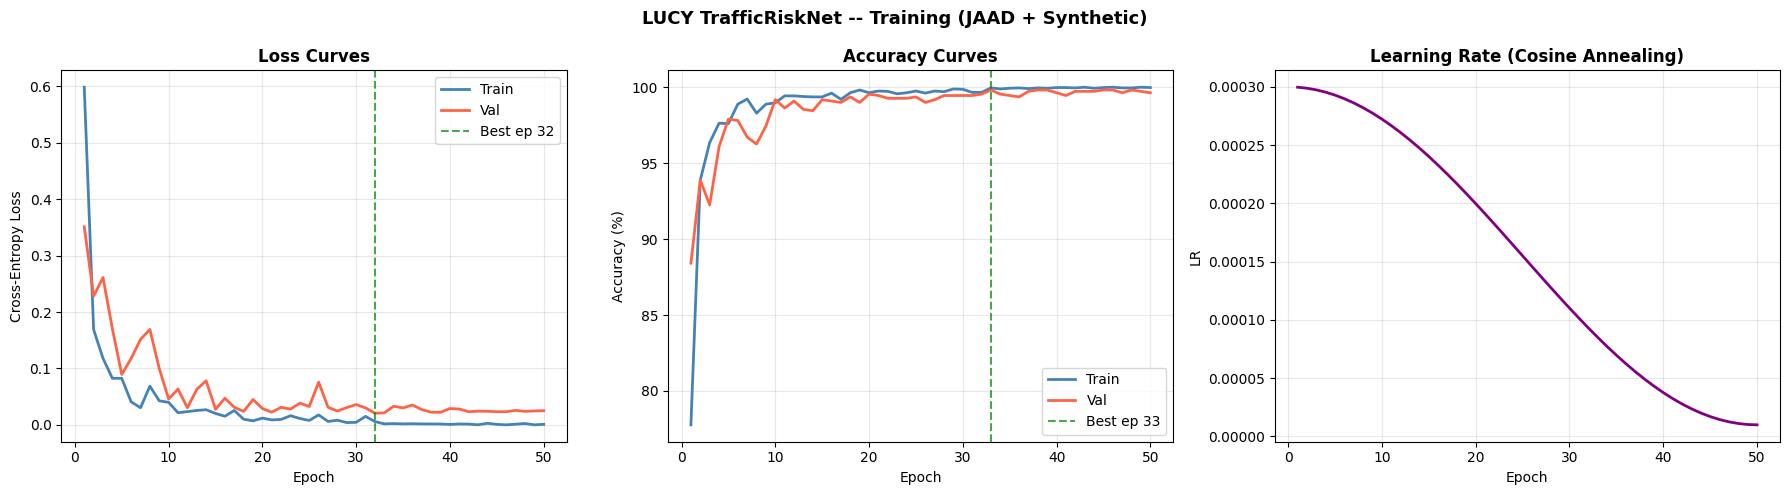

Final train loss  : 0.0009
Final val   loss  : 0.0251
Best  val   acc   : 99.82%  (epoch 33)
Final train acc   : 99.98%
Final val   acc   : 99.64%


In [9]:
epochs_range = range(1, len(history['train_loss'])+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato',    lw=2)
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Best ep {best_ep}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, [x*100 for x in history['train_acc']], label='Train', color='steelblue', lw=2)
axes[1].plot(epochs_range, [x*100 for x in history['val_acc']],   label='Val',   color='tomato',    lw=2)
best_ep_acc = int(np.argmax(history['val_acc'])) + 1
axes[1].axvline(best_ep_acc, color='green', ls='--', alpha=0.7, label=f'Best ep {best_ep_acc}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning rate schedule
axes[2].plot(epochs_range, history['lr'], color='purple', lw=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_title('Learning Rate (Cosine Annealing)', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('LUCY TrafficRiskNet -- Training (JAAD + Synthetic)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/nb3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final train loss  : {history["train_loss"][-1]:.4f}')
print(f'Final val   loss  : {history["val_loss"][-1]:.4f}')
print(f'Best  val   acc   : {max(history["val_acc"])*100:.2f}%  (epoch {best_ep_acc})')
print(f'Final train acc   : {history["train_acc"][-1]*100:.2f}%')
print(f'Final val   acc   : {history["val_acc"][-1]*100:.2f}%')

## 7. Evaluation Metrics on Validation Set

In [10]:
# Collect all predictions on the validation set
all_preds, all_labels, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for toks, masks, labels in val_dl:
        toks, masks = toks.to(DEVICE), masks.to(DEVICE)
        out = model(toks, masks)
        probs = out['probs'].cpu().numpy()
        preds = out['probs'].argmax(-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
        all_probs.extend(probs.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean()
print(f'Validation samples : {len(all_labels)}')
print(f'Overall accuracy   : {overall_acc*100:.2f}%')
print()
for cls in range(3):
    mask = all_labels == cls
    cls_acc = (all_preds[mask] == cls).mean() if mask.sum() > 0 else 0.0
    print(f'  {RISK_CLASSES[cls]:8s}  n={mask.sum():4d}  acc={cls_acc*100:.1f}%')

Validation samples : 1096
Overall accuracy   : 99.82%

  SAFE      n= 210  acc=99.0%
  WARNING   n= 454  acc=100.0%
  CRITICAL  n= 432  acc=100.0%


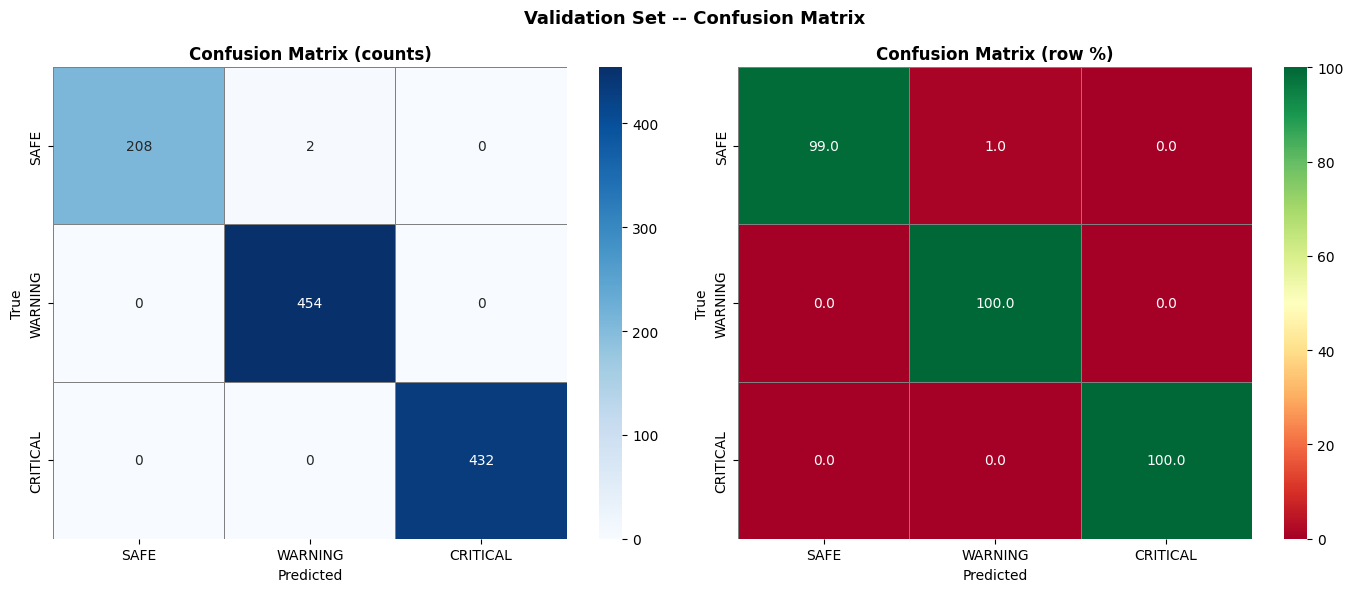

In [11]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
if HAS_SKLEARN:
    cm     = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=RISK_CLASSES, yticklabels=RISK_CLASSES,
                linewidths=0.5, linecolor='gray')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')

    # Normalized %
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
                xticklabels=RISK_CLASSES, yticklabels=RISK_CLASSES,
                linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_title('Confusion Matrix (row %)', fontweight='bold')

    plt.suptitle('Validation Set -- Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/nb3_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('sklearn not available -- skipping confusion matrix')

Classification Report:
              precision    recall  f1-score   support

        SAFE       1.00      0.99      1.00       210
     WARNING       1.00      1.00      1.00       454
    CRITICAL       1.00      1.00      1.00       432

    accuracy                           1.00      1096
   macro avg       1.00      1.00      1.00      1096
weighted avg       1.00      1.00      1.00      1096



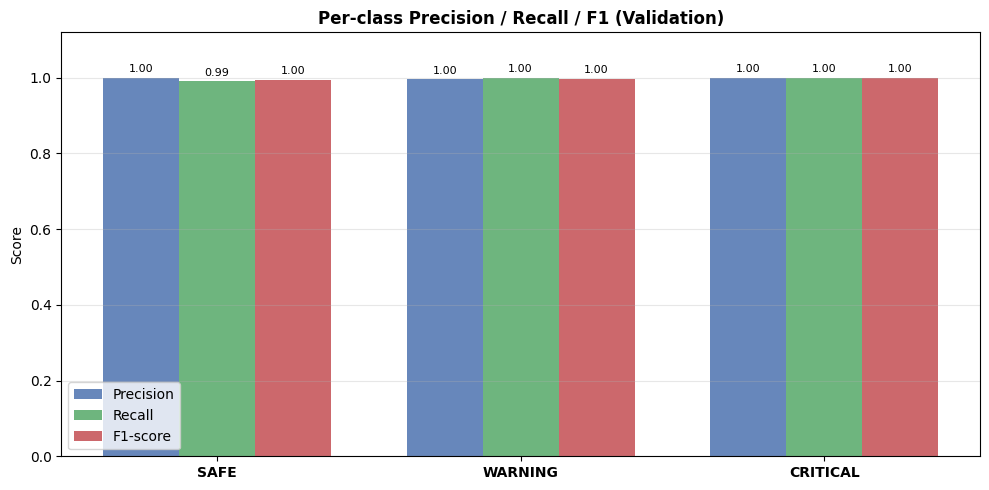

Macro F1  : 99.77%
Weighted F1: 99.82%


In [12]:
# ── Per-class Precision / Recall / F1 ────────────────────────────────────────
if HAS_SKLEARN:
    report = classification_report(all_labels, all_preds,
                                   target_names=RISK_CLASSES, output_dict=True)
    print('Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=RISK_CLASSES))

    # Bar chart: P / R / F1 per class
    metrics_names = ['precision', 'recall', 'f1-score']
    x = np.arange(len(RISK_CLASSES))
    width = 0.25
    colors = ['#4C72B0', '#55A868', '#C44E52']

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, metric in enumerate(metrics_names):
        vals = [report[cls][metric] for cls in RISK_CLASSES]
        bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(), color=colors[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(RISK_CLASSES, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.set_title('Per-class Precision / Recall / F1 (Validation)', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('output/nb3_per_class_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Macro F1  : {report["macro avg"]["f1-score"]*100:.2f}%')
    print(f'Weighted F1: {report["weighted avg"]["f1-score"]*100:.2f}%')
else:
    print('sklearn not available -- skipping per-class report')

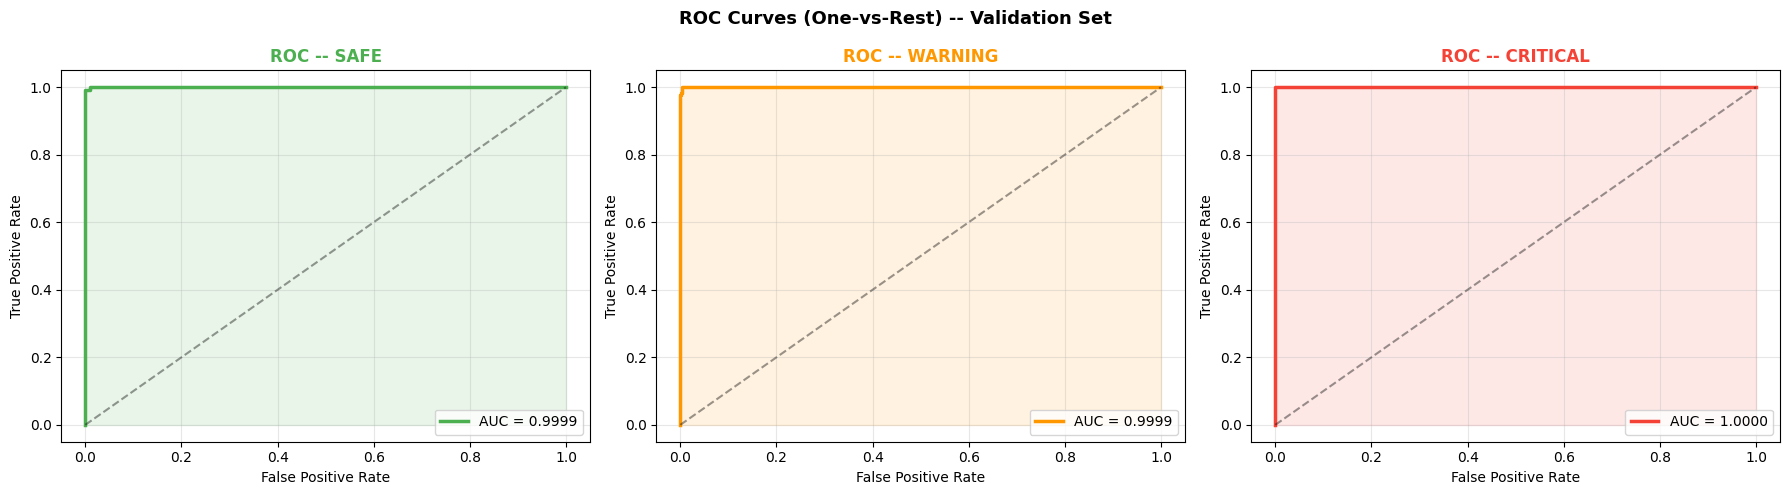

  AUC SAFE    : 0.9999
  AUC WARNING : 0.9999
  AUC CRITICAL: 1.0000
  Mean AUC        : 0.9999


In [14]:
# ── ROC Curves (One-vs-Rest) ─────────────────────────────────────────────────
if HAS_SKLEARN:
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(all_labels, classes=[0,1,2])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    auc_scores = []
    for cls in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, cls], all_probs[:, cls])
        roc_auc     = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        color = ['#4CAF50','#FF9800','#F44336'][cls]
        axes[cls].plot(fpr, tpr, color=color, lw=2.5,
                       label=f'AUC = {roc_auc:.4f}')
        axes[cls].plot([0,1],[0,1], 'k--', alpha=0.4)
        axes[cls].fill_between(fpr, tpr, alpha=0.12, color=color)
        axes[cls].set_xlabel('False Positive Rate')
        axes[cls].set_ylabel('True Positive Rate')
        axes[cls].set_title(f'ROC -- {RISK_CLASSES[cls]}', fontweight='bold', color=color)
        axes[cls].legend(loc='lower right')
        axes[cls].grid(alpha=0.3)

    plt.suptitle('ROC Curves (One-vs-Rest) -- Validation Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/nb3_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    for cls in range(3):
        print(f'  AUC {RISK_CLASSES[cls]:8s}: {auc_scores[cls]:.4f}')
    print(f'  Mean AUC        : {np.mean(auc_scores):.4f}')
else:
    print('sklearn not available -- skipping ROC curves')

## 8. Comparison: Synthetic-only vs JAAD-mixed

Model Comparison on Validation Set
Metric                           Synth-only   JAAD-mixed      Delta
--------------------------------------------------------------------
Overall Accuracy                     54.29%        99.82%  +  +45.53%
Macro F1                             51.43%        99.77%  +  +48.34%
SAFE     F1                          65.68%        99.52%  +  +33.84%
WARNING  F1                          23.53%        99.78%  +  +76.25%
CRITICAL F1                          65.08%       100.00%  +  +34.92%


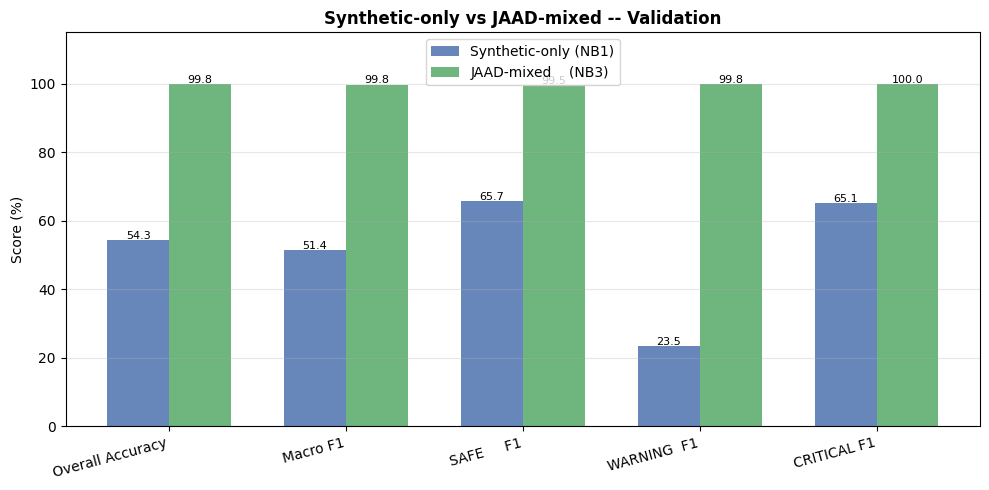

In [15]:
# Load the synthetic-only model (Notebook 1) and compare on the same val set
if os.path.exists(SYNTH_PATH) and HAS_SKLEARN:
    synth_model = TrafficRiskNet().to(DEVICE)
    synth_model.load_state_dict(torch.load(SYNTH_PATH, map_location=DEVICE))
    synth_model.eval()

    s_preds, s_labels = [], []
    with torch.no_grad():
        for toks, masks, labels in val_dl:
            toks, masks = toks.to(DEVICE), masks.to(DEVICE)
            out = synth_model(toks, masks)
            s_preds.extend(out['probs'].argmax(-1).cpu().numpy().tolist())
            s_labels.extend(labels.numpy().tolist())

    s_preds  = np.array(s_preds)
    s_labels = np.array(s_labels)
    synth_acc = (s_preds == s_labels).mean()
    jaad_acc  = (all_preds == all_labels).mean()

    synth_report = classification_report(s_labels, s_preds,
                                          target_names=RISK_CLASSES, output_dict=True)
    jaad_report  = classification_report(all_labels, all_preds,
                                          target_names=RISK_CLASSES, output_dict=True)

    print('Model Comparison on Validation Set')
    print(f'{"Metric":30s} {"Synth-only":>12s} {"JAAD-mixed":>12s} {"Delta":>10s}')
    print('-'*68)
    metrics_compare = [
        ('Overall Accuracy',   synth_acc,
                               jaad_acc),
        ('Macro F1',           synth_report['macro avg']['f1-score'],
                               jaad_report['macro avg']['f1-score']),
        ('SAFE     F1',        synth_report['SAFE']['f1-score'],
                               jaad_report['SAFE']['f1-score']),
        ('WARNING  F1',        synth_report['WARNING']['f1-score'],
                               jaad_report['WARNING']['f1-score']),
        ('CRITICAL F1',        synth_report['CRITICAL']['f1-score'],
                               jaad_report['CRITICAL']['f1-score']),
    ]
    for name, sv, jv in metrics_compare:
        delta = jv - sv
        sign  = '+' if delta >= 0 else ''
        print(f'{name:30s} {sv*100:>11.2f}%  {jv*100:>11.2f}%  {sign}{delta*100:>+8.2f}%')

    # Visual comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    labels_bar = [m[0] for m in metrics_compare]
    synth_vals = [m[1]*100 for m in metrics_compare]
    jaad_vals  = [m[2]*100 for m in metrics_compare]
    x = np.arange(len(labels_bar))
    w = 0.35
    b1 = ax.bar(x-w/2, synth_vals, w, label='Synthetic-only (NB1)', color='#4C72B0', alpha=0.85)
    b2 = ax.bar(x+w/2, jaad_vals,  w, label='JAAD-mixed    (NB3)', color='#55A868', alpha=0.85)
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels_bar, rotation=15, ha='right')
    ax.set_ylim(0, 115); ax.set_ylabel('Score (%)')
    ax.set_title('Synthetic-only vs JAAD-mixed -- Validation', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('output/nb3_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
elif not os.path.exists(SYNTH_PATH):
    print(f'Notebook 1 weights not found at {SYNTH_PATH} -- run Notebook 1 first')
else:
    print('sklearn not available -- skipping comparison')

## 9. Probability Distribution Analysis

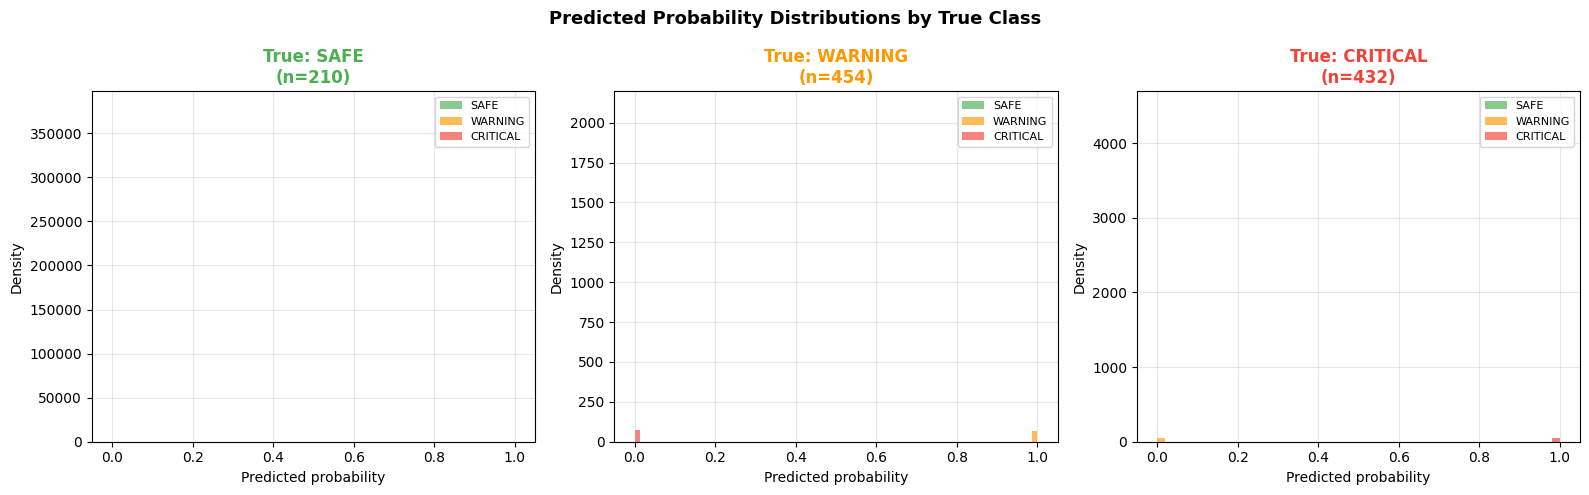

Mean predicted probability for each true class:
  True SAFE    : SAFE=0.990  WARNING=0.010  CRITICAL=0.000
  True WARNING : SAFE=0.000  WARNING=0.999  CRITICAL=0.001
  True CRITICAL: SAFE=0.000  WARNING=0.003  CRITICAL=0.997


In [16]:
# Show predicted probability distributions per true class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4CAF50', '#FF9800', '#F44336']

for true_cls in range(3):
    mask = all_labels == true_cls
    if mask.sum() == 0:
        axes[true_cls].axis('off'); continue
    cls_probs = all_probs[mask]  # (n, 3)
    ax = axes[true_cls]
    for pred_cls in range(3):
        ax.hist(cls_probs[:, pred_cls], bins=25, alpha=0.65,
                color=colors[pred_cls], label=RISK_CLASSES[pred_cls],
                density=True)
    ax.set_title(f'True: {RISK_CLASSES[true_cls]}\n(n={mask.sum()})',
                 fontweight='bold', color=colors[true_cls])
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Predicted Probability Distributions by True Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/nb3_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('Mean predicted probability for each true class:')
for true_cls in range(3):
    mask = all_labels == true_cls
    if mask.sum() == 0: continue
    means = all_probs[mask].mean(axis=0)
    row = '  '.join(f'{RISK_CLASSES[i]}={means[i]:.3f}' for i in range(3))
    print(f'  True {RISK_CLASSES[true_cls]:8s}: {row}')

## Conclusions

### Dataset
| Source | Sequences | Label method |
|---|---|---|
| JAAD (real bboxes) | up to 3x1200 | `cross/action/look` attributes |
| Synthetic (NB1 generators) | 3x1000 | geometry-based scene generation |
| **Total** | **~9600** | 80/20 train/val split |

### Architecture
Same `TrafficRiskNet` as Notebook 1 (SpatialRiskTransformer + BiGRU). Trained from scratch on the mixed dataset.

### Key improvements over synthetic-only
- Real pedestrian trajectories from 150 JAAD videos (1920x1080)
- Behavioral labels derived from expert human annotation
- Weighted sampling ensures class balance during training
- Model weights saved to `models/traffic_risk_jaad.pth`

### Next step
**Notebook 4**: Update `engines/deep_traffic_engine.py` and `main.py` to load `traffic_risk_jaad.pth` and run the full end-to-end pipeline.